In [1]:
pip install hmmlearn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, cohen_kappa_score, balanced_accuracy_score, matthews_corrcoef, f1_score
import matplotlib.pyplot as plt
from hmmlearn import hmm

In [8]:

df = pd.read_csv('final_pred_test_Best.csv')

# The exact order Doherty used for their matrices
classes = ['sleep', 'sedentary', 'light', 'moderate-vigorous']
label_to_idx = {label: i for i, label in enumerate(classes)}
idx_to_label = {i: label for i, label in enumerate(classes)}

# Convert text predictions to numbers (0, 1, 2, 3) and reshape for hmmlearn
obs_seq = df['model_preds'].map(label_to_idx).values.reshape(-1, 1)

#emission and transition matrices from shinng + Aiden
eps = 0.0000000001
# trans_mat = np.array([
#     [99.95, eps, 0.05, eps] ,
#     [eps, 99.48, 0.42, 0.1],
#     [eps, 1.62, 97.13, 1.26],
#     [0.1, 0.1, 0.73, 99.06]
# ])/100

# emiss_mat = np.array([
#     [93.49, 3.21, 2.52, 0.78],
#     [3.7, 78.94, 12.93, 4.44],
#     [2.69, 14.97, 61.91, 20.44],
#     [0.77, 3.95, 15.97, 79.31]
# ])/100
#Tsanas matrices
trans_mat = np.array([ 
[0.997109888512663, 0.000733000351225279, 0.00206567420681723, 9.14369292945087e-05],
[0.00108627516846909, 0.960569872017390, 0.0369983749104777, 0.00134547790366304],
[0.00284685754365777, 0.0864345280048417, 0.892562183490390, 0.0181564309611102],
[0.000520942707006747, 0.0224529756733128, 0.0948039637387253, 0.882200000000000]
])
emiss_mat = np.array([
[0.982015268771188, 0.0156694193026902, 0.00161392272299018, 0.000701389203131364],
[0.0123908104797718, 0.888616805970494, 0.0984801290914215, 0.000512254458313088],
[0.00550550435498852, 0.245212550218493, 0.718583286602337, 0.0306986588241805],
[8.50340136054422e-05, 0.0593443781866310, 0.427762045524215, 0.512835956268370]
])

# Normalize rows to sum to exactly 1
emiss_mat = emiss_mat / emiss_mat.sum(axis=1, keepdims=True)
trans_mat = trans_mat / trans_mat.sum(axis=1, keepdims=True)

model = hmm.CategoricalHMM(n_components=4)
# intiialise with our emission and transition matrices
model.startprob_ = np.array([0.25, 0.25, 0.25, 0.25]) # Assume the sequence can start on any activity
model.transmat_ = trans_mat
model.emissionprob_ = emiss_mat

 
smoothed_idx = model.predict(obs_seq)

# Convert smoothed numbers back to text labels
df['hmm_smoothed'] = [idx_to_label[i] for i in smoothed_idx]

# print accuracies for new and old
old_acc = (df['true_labels'] == df['model_preds']).mean()
new_acc = (df['true_labels'] == df['hmm_smoothed']).mean()
print(f"Original BiLSTM Accuracy: {old_acc:.4f}")
print(f"HMM Smoothed Accuracy:    {new_acc:.4f}")


Original BiLSTM Accuracy: 0.8926
HMM Smoothed Accuracy:    0.8918


In [18]:
df.head()

,true_labels,model_preds,hmm_smoothed
0,sleep,sleep,sleep
1,sleep,sleep,sleep
2,sleep,sleep,sleep
3,sleep,sleep,sleep
4,sleep,sleep,sleep


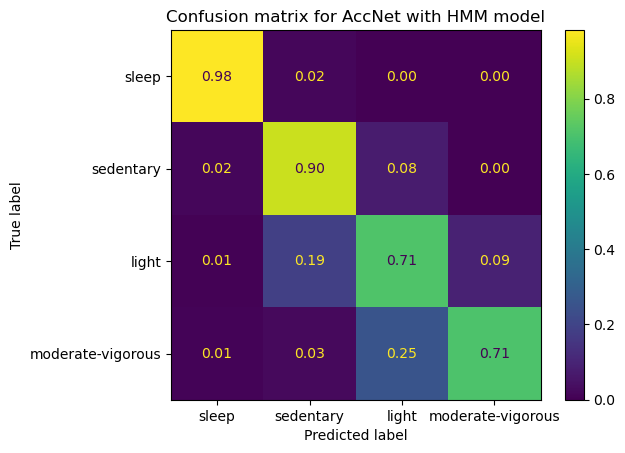

Metrics report for the AccNet: 

                   precision    recall  f1-score   support

            light       0.74      0.71      0.73     16539
moderate-vigorous       0.61      0.71      0.66      3850
        sedentary       0.91      0.90      0.90     41291
            sleep       0.98      0.98      0.98     36012

         accuracy                           0.89     97692
        macro avg       0.81      0.83      0.82     97692
     weighted avg       0.89      0.89      0.89     97692

 test/bacc: 0.826
  test/phi: 0.835
test/kappa: 0.835
test/f1: 0.817


In [9]:
PAorder = ['sleep', 'sedentary','light','moderate-vigorous']

pred = df
ConfusionMatrixDisplay.from_predictions( pred['true_labels'], pred['hmm_smoothed'], labels=PAorder,
                                         normalize = 'true', values_format = '.2f')
plt.title('Confusion matrix for AccNet with HMM model')
plt.show()
print('Metrics report for the AccNet: \n')
report = classification_report( pred['true_labels'], pred['hmm_smoothed'], digits=2)
print(report)

bacc = balanced_accuracy_score( pred['true_labels'], pred['hmm_smoothed'])
kappa = cohen_kappa_score( pred['true_labels'], pred['hmm_smoothed'])
phi = matthews_corrcoef(pred['true_labels'], pred['hmm_smoothed'])
f1 = f1_score(pred['true_labels'], pred['hmm_smoothed'], average = 'macro')

print(f" test/bacc: {bacc:.3f}")
print(f"  test/phi: {phi:.3f}")
print(f"test/kappa: {kappa:.3f}")
print(f"test/f1: {f1:.3f}")